# Example workflow based on a HydroFrame domain

This notebook walks through a typical workflow with data from the HydroData database. You can read more about how to get data from HydroData and how to clip a domain in the documentation pages for the [`subsettools`](https://hydroframesubsettools.readthedocs.io/en/latest/) and [`hf_hydrodata`](https://hf-hydrodata.readthedocs.io/en/latest/) packages. Here we follow "Option 3" from the main example workflow, using a river mask to have more control over the set of target points used in the processing. We suggest working through this example notebook first, to become more familiar with the various processing options available in priority_flow.

In [9]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Import from priority_flow package (all at package level via __init__.py)
from priority_flow import (
    init_queue,
    d4_traverse_b,
    load_dem,
    load_watershed_mask,
    load_river_mask,
    drainage_area,
    calc_subbasins,
    calc_stream_order,
    river_smooth,
    path_extract,
    slope_calc_standard,
    riv_slope,
)

from parflow.tools.io import read_pfb, write_pfb

In [10]:
# Read in clipped data
DEM = read_pfb('conus2_domain.elevation.pfb')[0, :, :]
watershed_mask = read_pfb('conus2_domain.mask.pfb')[0, :, :]
river_mask = read_pfb('conus2_domain.river_mask.pfb')[0, :, :]

nx, ny = DEM.shape
print(f"Domain dimensions: nx={nx}, ny={ny}")
print(f"DEM elevation range: {DEM.min():.2f} to {DEM.max():.2f}")

Domain dimensions: nx=89, ny=107
DEM elevation range: 61.78 to 1070.43


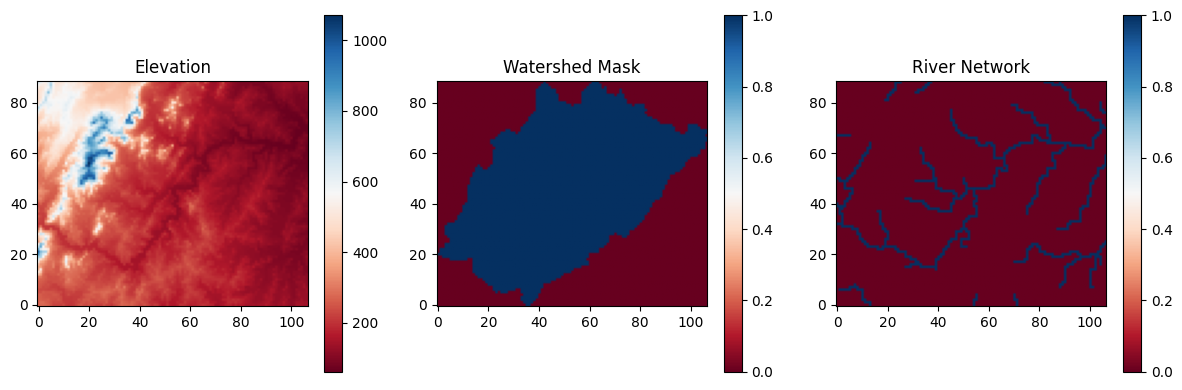

In [11]:
# Plot inputs
def _plot_inputs():
    """Plot the three input datasets."""
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    im0 = axes[0].imshow(DEM, cmap='RdBu', origin='lower')
    axes[0].set_title("Elevation")
    plt.colorbar(im0, ax=axes[0])
    im1 = axes[1].imshow(watershed_mask, cmap='RdBu', origin='lower')
    axes[1].set_title("Watershed Mask")
    plt.colorbar(im1, ax=axes[1])
    im2 = axes[2].imshow(river_mask, cmap='RdBu', origin='lower')
    axes[2].set_title("River Network")
    plt.colorbar(im2, ax=axes[2])
    plt.tight_layout()
    plt.savefig("workflow_inputs.png", dpi=150)
    plt.show()
    plt.close()
_plot_inputs()

### Step 1: Processing the DEM

In [12]:
# Setup the queue
init = init_queue(DEM, domainmask=watershed_mask, initmask=river_mask)

No border provided, setting border using domain mask


In [13]:
# Process the DEM
trav_hs = d4_traverse_b(
    DEM.copy(),
    init["queue"].copy(),
    init["marked"].copy(),
    mask=watershed_mask.copy(),
    basins=init["basins"].copy(),
    epsilon=0,
    n_chunk=10,
)

inital queue: 2 Not splitting


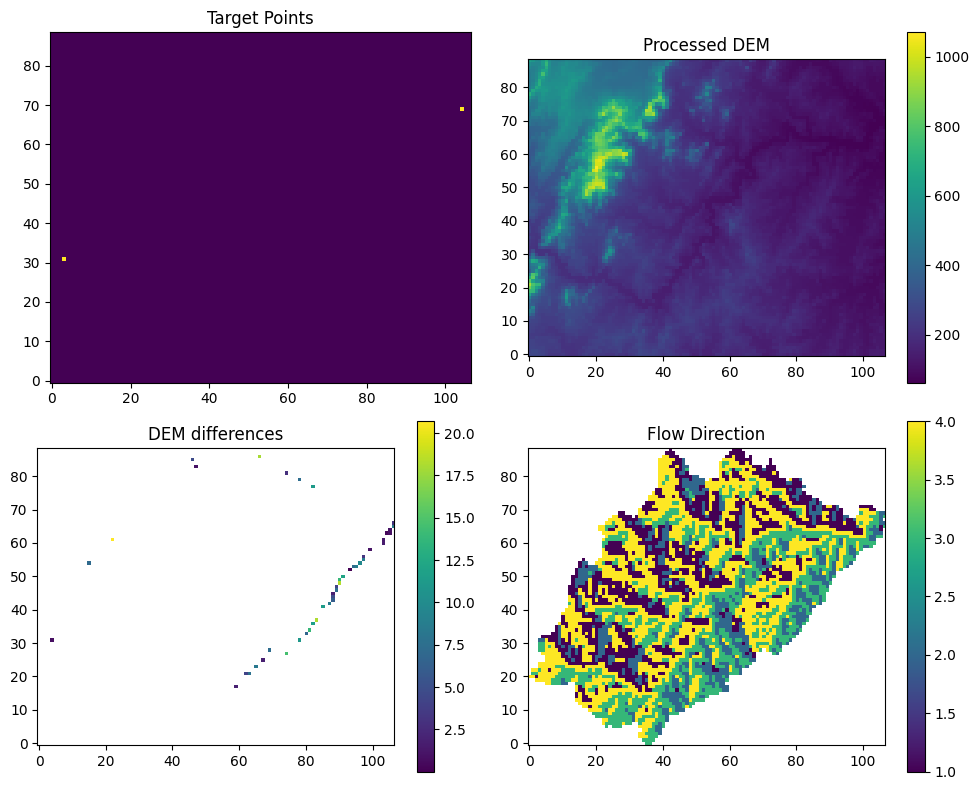

In [15]:
# Plot the results of the traversal

def _plot_step1(trav_hs, dem_diff, targets):
    """Plot DEM processing results."""
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes[0, 0].imshow(np.where(np.isnan(targets), 0, 1), cmap='viridis', origin='lower')
    axes[0, 0].set_title("Target Points")
    im1 = axes[0, 1].imshow(trav_hs["dem"], cmap='viridis', origin='lower')
    axes[0, 1].set_title("Processed DEM")
    plt.colorbar(im1, ax=axes[0, 1])
    im2 = axes[1, 0].imshow(dem_diff, cmap='viridis', origin='lower')
    axes[1, 0].set_title("DEM differences")
    plt.colorbar(im2, ax=axes[1, 0])
    im3 = axes[1, 1].imshow(trav_hs["direction"], cmap='viridis', origin='lower')
    axes[1, 1].set_title("Flow Direction")
    plt.colorbar(im3, ax=axes[1, 1])
    plt.tight_layout()
    plt.savefig("workflow_step1.png", dpi=150)
    plt.show()
    plt.close()

# Some calculations for plotting
dem_diff = trav_hs["dem"] - DEM
dem_diff[dem_diff == 0] = np.nan
targets = init["marked"].copy()
targets[targets == 0] = np.nan

_plot_step1(trav_hs, dem_diff, targets)

## Step 2: Smoothing along the drainage network

In [18]:
# Calculate the drainage area
area = drainage_area(
    trav_hs["direction"],
    mask=watershed_mask,
    printflag=False,
)

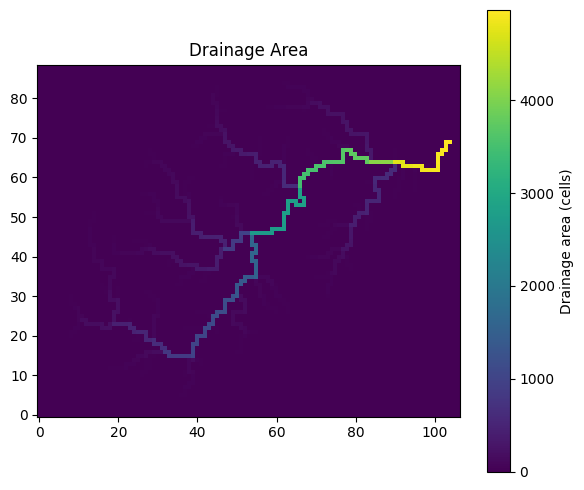

In [19]:
def _plot_drainage_area(area: np.ndarray) -> None:
    """Plot drainage area (like R: image.plot(area, main='drainage Area'))."""
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(area, cmap="viridis", origin='lower')
    ax.set_title("Drainage Area")
    plt.colorbar(im, ax=ax, label="Drainage area (cells)")
    plt.tight_layout()
    plt.savefig("workflow_drainage_area.png", dpi=150)
    plt.show()
    plt.close()

_plot_drainage_area(area)

In [21]:
# Use a drainage area threshold to define a river network
# riv_th: cells with >= riv_th cells draining to it count as rivers
subbasin = calc_subbasins(
    trav_hs["direction"],
    area=area,
    mask=watershed_mask,
    riv_th=60,
    merge_th=0,
)

In [22]:
# Calculate stream order (optional)
stream_order = calc_stream_order(
    subbasin["summary"][:, 0],
    subbasin["summary"][:, 5],
    subbasin["segments"].copy(),
)

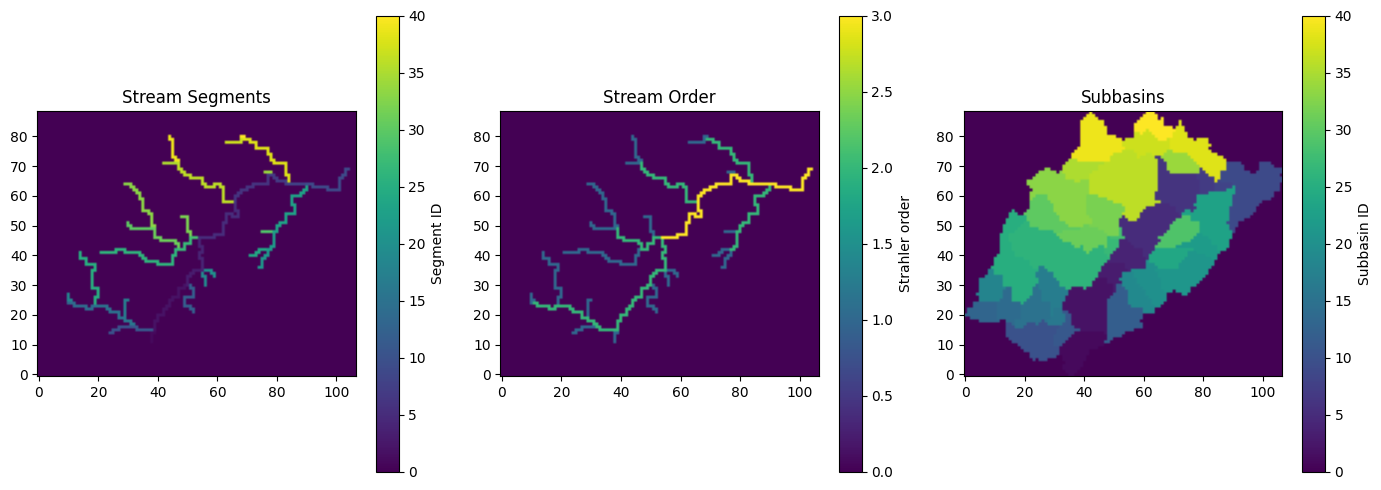

In [23]:
def _plot_stream_network(
    subbasin: dict,
    stream_order: dict,
) -> None:
    """Plot stream segments, stream order, and subbasins (like R par(mfrow=c(1,3)))."""
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    im0 = axes[0].imshow(subbasin["segments"], cmap="viridis", origin='lower')
    axes[0].set_title("Stream Segments")
    plt.colorbar(im0, ax=axes[0], label="Segment ID")
    im1 = axes[1].imshow(stream_order["order_mask"], cmap="viridis", origin='lower')
    axes[1].set_title("Stream Order")
    plt.colorbar(im1, ax=axes[1], label="Strahler order")
    im2 = axes[2].imshow(subbasin["subbasins"], cmap="viridis", origin='lower')
    axes[2].set_title("Subbasins")
    plt.colorbar(im2, ax=axes[2], label="Subbasin ID")
    plt.tight_layout()
    plt.savefig("workflow_stream_network.png", dpi=150)
    plt.show()
    plt.close()


_plot_stream_network(subbasin, stream_order)

In [24]:
# Smooth the DEM along river segments
riv_smooth_result = river_smooth(
    dem=trav_hs["dem"],
    direction=trav_hs["direction"],
    mask=watershed_mask,
    river_summary=subbasin["summary"],
    river_segments=subbasin["segments"],
    bank_epsilon=1,
)

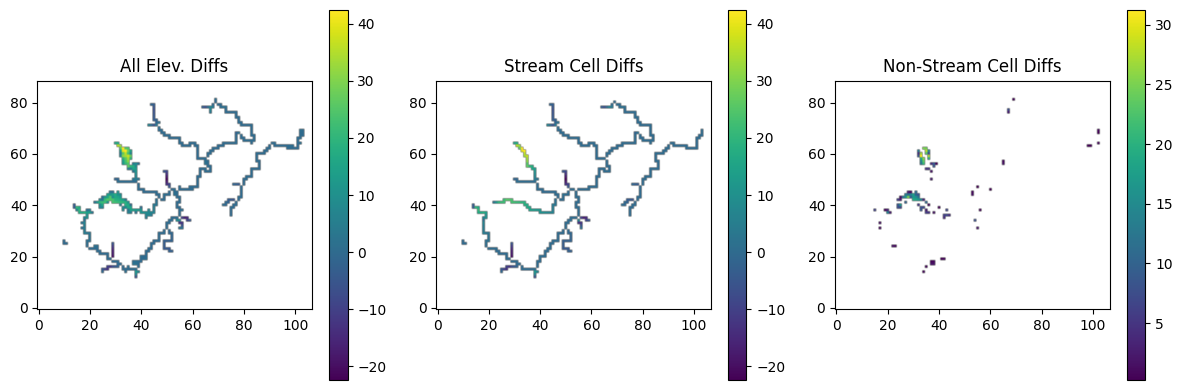

In [25]:
# Plot elevation differences from river smoothing
def _plot_river_smoothing():
    """Plot river smoothing results."""
    dif = riv_smooth_result["dem.adj"] - trav_hs["dem"]
    riv_mask = np.where(subbasin["segments"] > 0, 1, 0)
    hill_mask = 1 - riv_mask
    dif_hill = dif * hill_mask
    dif_riv = dif * riv_mask

    dif_plot = np.where(dif == 0, np.nan, dif)
    dif_riv_plot = np.where(dif_riv == 0, np.nan, dif_riv)
    dif_hill_plot = np.where(dif_hill == 0, np.nan, dif_hill)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    im0 = axes[0].imshow(dif_plot, cmap='viridis', origin='lower')
    axes[0].set_title("All Elev. Diffs")
    plt.colorbar(im0, ax=axes[0])
    im1 = axes[1].imshow(dif_riv_plot, cmap='viridis', origin='lower')
    axes[1].set_title("Stream Cell Diffs")
    plt.colorbar(im1, ax=axes[1])
    if np.any(~np.isnan(dif_hill_plot)):
        im2 = axes[2].imshow(dif_hill_plot, cmap='viridis', origin='lower')
        axes[2].set_title("Non-Stream Cell Diffs")
        plt.colorbar(im2, ax=axes[2])
    plt.tight_layout()
    plt.savefig("workflow_step2_smoothing.png", dpi=150)
    plt.show()
    plt.close()

_plot_river_smoothing()

## Step 3: Calculate the slopes

In [26]:
# Calculate the slopes for the entire domain
slopes_calc = slope_calc_standard(
    dem=riv_smooth_result["dem.adj"].copy(),
    direction=trav_hs["direction"].copy(),
    mask=watershed_mask.copy(),
    minslope=1e-5,
    maxslope=1,
    dx=1000,
    dy=1000,
    secondary_th=-1,
)

In [27]:
# (Optional) Adjust the slopes along the river cells
river_mask_slope = np.where(subbasin["segments"] > 0, 1, 0)
slopes_calc2 = riv_slope(
    direction=trav_hs["direction"].copy(),
    slopex=slopes_calc["slopex"].copy(),
    slopey=slopes_calc["slopey"].copy(),
    minslope=1e-4,
    river_mask=watershed_mask.copy(),
    remove_sec=True,
)

slopex = slopes_calc2["slopex"]
slopey = slopes_calc2["slopey"]

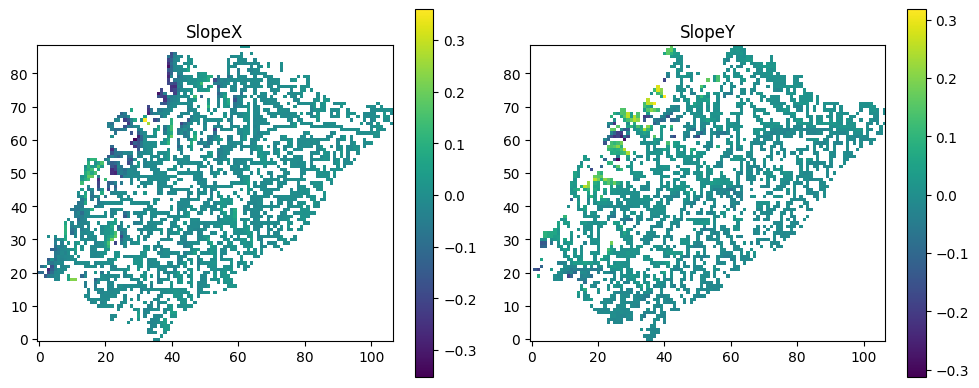

In [28]:
# Plot the slopes
def _plot_slopes(slopex: np.ndarray, slopey: np.ndarray) -> None:
    """
    Plot resulting slopes in x and y directions (R analogue: image.plot of sxplot, syplot).
    """
    sxplot = np.where(slopex == 0, np.nan, slopex)
    syplot = np.where(slopey == 0, np.nan, slopey)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    im0 = axes[0].imshow(sxplot, cmap="viridis", origin='lower')
    axes[0].set_title("SlopeX")
    plt.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(syplot, cmap="viridis", origin='lower')
    axes[1].set_title("SlopeY")
    plt.colorbar(im1, ax=axes[1])

    plt.tight_layout()
    plt.savefig("workflow_slopes.png", dpi=150)
    plt.show()
    plt.close()


_plot_slopes(slopex, slopey)

## Step 4: Write slope files out in ParFlow pfb format

In [29]:
write_pfb("slopex.pfb", slopex)
write_pfb("slopey.pfb", slopey)
write_pfb("dem_processed.pfb", riv_smooth_result["dem.adj"])
write_pfb("flow_direction.pfb", trav_hs["direction"])